# Round 3 Market EDA

This notebook explores `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`, and the 10 `VEV_*` vouchers in `ROUND_3`.

Conventions used below:
- The notebook auto-discovers the available `prices_round_3_day_*.csv` and `trades_round_3_day_*.csv` files and uses all of them.
- The discovered files are ordered chronologically by their day suffix and relabeled internally as historical days 1/2/3.
- Time-to-expiry for option work follows the round note: historical day 1 -> `8d`, day 2 -> `7d`, day 3 -> `6d`.
- Black-Scholes uses `r = 0` and no dividends.
- Strikes with observed prices deviating from BS by more than 2% are flagged as primary candidates.

The figures are produced in the requested order, followed by a compact candidate screen and a few extra diagnostics.

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ROUND_3").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "ROUND_3"
PLOT_DIR = REPO_ROOT / "data_exploration" / "round3_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

UNDERLYING = "VELVETFRUIT_EXTRACT"
HYDROGEL = "HYDROGEL_PACK"
OPTION_PREFIX = "VEV_"
TIME_BLOCK = 1_000_000

PRICE_FILES = sorted(DATA_DIR.glob("prices_round_3_day_*.csv"), key=lambda p: int(p.stem.split("_")[-1]))
TRADE_FILES = sorted(DATA_DIR.glob("trades_round_3_day_*.csv"), key=lambda p: int(p.stem.split("_")[-1]))
FILE_DAYS = [int(path.stem.split("_")[-1]) for path in PRICE_FILES]
DAY_INDEX_BY_FILE_DAY = {file_day: idx for idx, file_day in enumerate(FILE_DAYS)}
HISTORICAL_DAY_BY_FILE_DAY = {file_day: idx + 1 for idx, file_day in enumerate(FILE_DAYS)}
TTE_BY_FILE_DAY = {file_day: float(9 - historical_day) for file_day, historical_day in HISTORICAL_DAY_BY_FILE_DAY.items()}
BOUNDARIES = [TIME_BLOCK * idx for idx in range(1, len(FILE_DAYS))]


def savefig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(PLOT_DIR / name, dpi=180, bbox_inches="tight")

In [31]:
def load_prices() -> pd.DataFrame:
    frames = []
    for path in PRICE_FILES:
        file_day = int(path.stem.split("_")[-1])
        df = pd.read_csv(path, sep=";")
        df["file_day"] = file_day
        df["day_index"] = DAY_INDEX_BY_FILE_DAY[file_day]
        df["historical_day"] = HISTORICAL_DAY_BY_FILE_DAY[file_day]
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True)
    prices = prices.sort_values(["product", "day_index", "timestamp"]).reset_index(drop=True)
    prices["mid_price"] = pd.to_numeric(prices["mid_price"], errors="coerce")
    prices["bid_price_1"] = pd.to_numeric(prices["bid_price_1"], errors="coerce")
    prices["ask_price_1"] = pd.to_numeric(prices["ask_price_1"], errors="coerce")
    prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]
    prices["session_time"] = prices["day_index"] * TIME_BLOCK + prices["timestamp"]
    prices["log_mid"] = np.log(prices["mid_price"].clip(lower=1e-9))
    prices["log_return"] = prices.groupby(["product", "file_day"])["log_mid"].diff()
    prices["pct_return"] = prices.groupby(["product", "file_day"])["mid_price"].pct_change()
    return prices


def load_trades() -> pd.DataFrame:
    frames = []
    for path in TRADE_FILES:
        file_day = int(path.stem.split("_")[-1])
        df = pd.read_csv(path, sep=";")
        df["file_day"] = file_day
        df["day_index"] = DAY_INDEX_BY_FILE_DAY[file_day]
        df["historical_day"] = HISTORICAL_DAY_BY_FILE_DAY[file_day]
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True)
    trades = trades.sort_values(["symbol", "day_index", "timestamp"]).reset_index(drop=True)
    trades["session_time"] = trades["day_index"] * TIME_BLOCK + trades["timestamp"]
    return trades


prices = load_prices()
trades = load_trades()

vev = prices[prices["product"] == UNDERLYING].copy()
hydro = prices[prices["product"] == HYDROGEL].copy()

for window in (20, 50, 100):
    vev[f"rv_{window}"] = vev.groupby("file_day")["log_return"].transform(lambda s: s.rolling(window).std())

print("Using price files:", [path.name for path in PRICE_FILES])
print("Using trade files:", [path.name for path in TRADE_FILES])
print("Historical day mapping:", HISTORICAL_DAY_BY_FILE_DAY)
print("TTE by file day:", TTE_BY_FILE_DAY)
print("Mid-price convention: same as EDA_round1.ipynb -> use the CSV 'mid_price' column directly, no recomputation.")

display(
    prices.groupby("product")
    .agg(rows=("product", "size"), mean_mid=("mid_price", "mean"), mean_spread=("spread", "mean"))
    .sort_index()
)

display(
    trades.groupby("symbol")
    .agg(trades=("symbol", "size"), total_quantity=("quantity", "sum"))
    .sort_index()
)

Using price files: ['prices_round_3_day_0.csv', 'prices_round_3_day_1.csv', 'prices_round_3_day_2.csv']
Using trade files: ['trades_round_3_day_0.csv', 'trades_round_3_day_1.csv', 'trades_round_3_day_2.csv']
Historical day mapping: {0: 1, 1: 2, 2: 3}
TTE by file day: {0: 8.0, 1: 7.0, 2: 6.0}
Mid-price convention: same as EDA_round1.ipynb -> use the CSV 'mid_price' column directly, no recomputation.


,rows,mean_mid,mean_spread
product,,,
HYDROGEL_PACK,30000,9990.806867,15.720800
VELVETFRUIT_EXTRACT,30000,5250.098100,4.988133
VEV_4000,30000,1250.109800,20.813467
VEV_4500,30000,750.109567,15.852667
VEV_5000,30000,255.022400,6.043333
VEV_5100,30000,166.805450,4.295833
VEV_5200,30000,95.548767,2.888133
VEV_5300,30000,46.759933,2.106800
VEV_5400,30000,15.951917,1.381433


,trades,total_quantity
symbol,,
HYDROGEL_PACK,1010,4078
VELVETFRUIT_EXTRACT,1372,8269
VEV_4000,464,940
VEV_4500,1,1
VEV_5000,1,1
VEV_5100,1,1
VEV_5200,18,63
VEV_5300,121,420
VEV_5400,225,787


In [32]:
# Scratch cell intentionally left blank.

In [33]:
def norm_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)


def norm_cdf(x):
    x = np.asarray(x, dtype=float)
    t = 1.0 / (1.0 + 0.2316419 * np.abs(x))
    poly = t * (
        0.319381530
        + t * (-0.356563782 + t * (1.781477937 + t * (-1.821255978 + t * 1.330274429)))
    )
    cdf = 1.0 - norm_pdf(np.abs(x)) * poly
    return np.where(x >= 0, cdf, 1.0 - cdf)


def bs_call_price(spot, strike, t, sigma):
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    t = np.asarray(t, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    intrinsic = np.maximum(spot - strike, 0.0)
    out = intrinsic.astype(float).copy()
    valid = (spot > 0) & (strike > 0) & (t > 0) & (sigma > 0)
    if not np.any(valid):
        return out

    vt = sigma[valid] * np.sqrt(t[valid])
    d1 = (np.log(spot[valid] / strike[valid]) + 0.5 * sigma[valid] ** 2 * t[valid]) / vt
    d2 = d1 - vt
    out[valid] = spot[valid] * norm_cdf(d1) - strike[valid] * norm_cdf(d2)
    return out


def implied_vol_call(price, spot, strike, t, max_iter=80):
    price = np.asarray(price, dtype=float)
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    t = np.asarray(t, dtype=float)

    out = np.full(price.shape, np.nan, dtype=float)
    intrinsic = np.maximum(spot - strike, 0.0)
    valid = (
        np.isfinite(price)
        & np.isfinite(spot)
        & np.isfinite(strike)
        & np.isfinite(t)
        & (spot > 0)
        & (strike > 0)
        & (t > 0)
        & (price >= intrinsic - 1e-9)
        & (price <= spot + 1e-9)
    )
    if not np.any(valid):
        return out

    target = price[valid]
    sv = spot[valid]
    kv = strike[valid]
    tv = t[valid]

    low = np.full_like(target, 1e-6)
    high = np.full_like(target, 2.0)
    too_low = bs_call_price(sv, kv, tv, high) < target
    while np.any(too_low):
        high = np.where(too_low, high * 2.0, high)
        too_low = (bs_call_price(sv, kv, tv, high) < target) & (high < 10.0)

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        mid_price = bs_call_price(sv, kv, tv, mid)
        go_higher = mid_price < target
        low = np.where(go_higher, mid, low)
        high = np.where(go_higher, high, mid)

    out[valid] = 0.5 * (low + high)
    return out


def bs_call_greeks(spot, strike, t, sigma):
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    t = np.asarray(t, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    delta = np.full_like(spot, np.nan, dtype=float)
    vega = np.full_like(spot, np.nan, dtype=float)
    theta = np.full_like(spot, np.nan, dtype=float)

    valid = (spot > 0) & (strike > 0) & (t > 0) & (sigma > 0)
    if not np.any(valid):
        return delta, vega, theta

    vt = sigma[valid] * np.sqrt(t[valid])
    d1 = (np.log(spot[valid] / strike[valid]) + 0.5 * sigma[valid] ** 2 * t[valid]) / vt
    d2 = d1 - vt

    delta[valid] = norm_cdf(d1)
    vega[valid] = spot[valid] * norm_pdf(d1) * np.sqrt(t[valid]) / 100.0
    theta[valid] = -(spot[valid] * norm_pdf(d1) * sigma[valid]) / (2.0 * np.sqrt(t[valid])) / 365.0
    return delta, vega, theta


spot = vev[["file_day", "timestamp", "session_time", "mid_price", "log_return"]].rename(
    columns={"mid_price": "spot_mid", "log_return": "spot_log_return"}
)

options = prices[prices["product"].str.startswith(OPTION_PREFIX)].copy()
options["strike"] = options["product"].str.split("_").str[1].astype(int)
options = options.merge(spot, on=["file_day", "timestamp", "session_time"], how="left")
options["tte_days"] = options["file_day"].map(TTE_BY_FILE_DAY).astype(float)
options["tte_years"] = options["tte_days"] / 365.0
options["intrinsic"] = np.maximum(options["spot_mid"] - options["strike"], 0.0)
options["time_value"] = (options["mid_price"] - options["intrinsic"]).clip(lower=0.0)
options["moneyness"] = options["spot_mid"] / options["strike"]
options["bounded_market_price"] = np.maximum(options["mid_price"], options["intrinsic"] + 1e-9)
options["bs_iv"] = implied_vol_call(
    options["bounded_market_price"].to_numpy(),
    options["spot_mid"].to_numpy(),
    options["strike"].to_numpy(),
    options["tte_years"].to_numpy(),
)
options["bs_price"] = bs_call_price(
    options["spot_mid"].to_numpy(),
    options["strike"].to_numpy(),
    options["tte_years"].to_numpy(),
    options["bs_iv"].to_numpy(),
)
options["model_price"] = np.where(np.isfinite(options["bs_price"]), options["bs_price"], options["intrinsic"])
options["abs_pct_deviation"] = (
    (options["mid_price"] - options["model_price"]).abs() / options["mid_price"].clip(lower=0.5)
)
options["candidate"] = options["abs_pct_deviation"] > 0.02

smile_daily = (
    options.groupby(["file_day", "strike"], as_index=False)
    .agg(
        median_iv=("bs_iv", "median"),
        mean_iv=("bs_iv", "mean"),
        mean_spot=("spot_mid", "mean"),
        mean_market_price=("mid_price", "mean"),
        mean_bs_price=("bs_price", "mean"),
        mean_time_value=("time_value", "mean"),
        flag_rate=("candidate", "mean"),
    )
)
smile_daily["moneyness"] = smile_daily["mean_spot"] / smile_daily["strike"]
smile_daily["tte_days"] = smile_daily["file_day"].map(TTE_BY_FILE_DAY)
smile_daily["flag_rate_pct"] = 100.0 * smile_daily["flag_rate"]

candidate_summary = (
    options.groupby(["file_day", "strike", "tte_days"], as_index=False)
    .agg(
        observed_mid=("mid_price", "mean"),
        bs_mid=("bs_price", "mean"),
        mean_abs_pct_dev=("abs_pct_deviation", "mean"),
        max_abs_pct_dev=("abs_pct_deviation", "max"),
        flag_rate=("candidate", "mean"),
    )
    .sort_values(["flag_rate", "mean_abs_pct_dev"], ascending=False)
)
candidate_summary["flag_rate_pct"] = 100.0 * candidate_summary["flag_rate"]

corr_frames = []
for day in FILE_DAYS:
    vev_day = vev.loc[vev["file_day"] == day, ["timestamp", "session_time", "mid_price", "log_return"]].rename(
        columns={"mid_price": "vev_mid", "log_return": "vev_log_return"}
    )
    hydro_day = hydro.loc[
        hydro["file_day"] == day, ["timestamp", "session_time", "mid_price", "log_return"]
    ].rename(columns={"mid_price": "hydro_mid", "log_return": "hydro_log_return"})
    merged = vev_day.merge(hydro_day, on=["timestamp", "session_time"], how="inner")
    merged["file_day"] = day
    merged["historical_day"] = HISTORICAL_DAY_BY_FILE_DAY[day]
    merged["rolling_corr_100"] = merged["vev_log_return"].rolling(100).corr(merged["hydro_log_return"])
    corr_frames.append(merged)

corr_df = pd.concat(corr_frames, ignore_index=True)

latest_day = FILE_DAYS[-1]
latest_timestamp = int(options.loc[options["file_day"] == latest_day, "timestamp"].max())
latest_snapshot = options[(options["file_day"] == latest_day) & (options["timestamp"] == latest_timestamp)].copy()
latest_snapshot = latest_snapshot.sort_values("strike").reset_index(drop=True)
latest_snapshot["delta"], latest_snapshot["vega_per_vol_point"], latest_snapshot["theta_per_day"] = bs_call_greeks(
    latest_snapshot["spot_mid"].to_numpy(),
    latest_snapshot["strike"].to_numpy(),
    latest_snapshot["tte_years"].to_numpy(),
    latest_snapshot["bs_iv"].to_numpy(),
)

print(f"Loaded {len(prices):,} price rows and {len(trades):,} trade rows.")
print(f"Flagged observations (>2% BS deviation): {int(options['candidate'].sum()):,}")
display(candidate_summary.head(15))

Loaded 360,000 price rows and 4,048 trade rows.
Flagged observations (>2% BS deviation): 0


,file_day,strike,tte_days,observed_mid,bs_mid,mean_abs_pct_dev,max_abs_pct_dev,flag_rate,flag_rate_pct
11,1,4500,7.0,748.40525,748.61645,2.826296e-04,6.258693e-03,0.0,0.0
1,0,4500,8.0,746.52160,746.72995,2.795352e-04,7.412399e-03,0.0,0.0
21,2,4500,6.0,755.40185,755.59960,2.626484e-04,7.947020e-03,0.0,0.0
20,2,4000,6.0,1255.39735,1255.52315,1.004094e-04,5.582137e-03,0.0,0.0
10,1,4000,7.0,1248.40795,1248.52775,9.630512e-05,4.769475e-03,0.0,0.0
0,0,4000,8.0,1246.52410,1246.63930,9.264997e-05,5.349794e-03,0.0,0.0
22,2,5000,6.0,258.54470,258.54485,5.469568e-07,1.865672e-03,0.0,0.0
9,0,6500,8.0,0.50000,0.50000,6.321358e-13,1.165290e-12,0.0,0.0
28,2,6000,6.0,0.50000,0.50000,5.834380e-13,1.151079e-12,0.0,0.0
29,2,6500,6.0,0.50000,0.50000,5.805362e-13,1.165290e-12,0.0,0.0


## Requested Plots

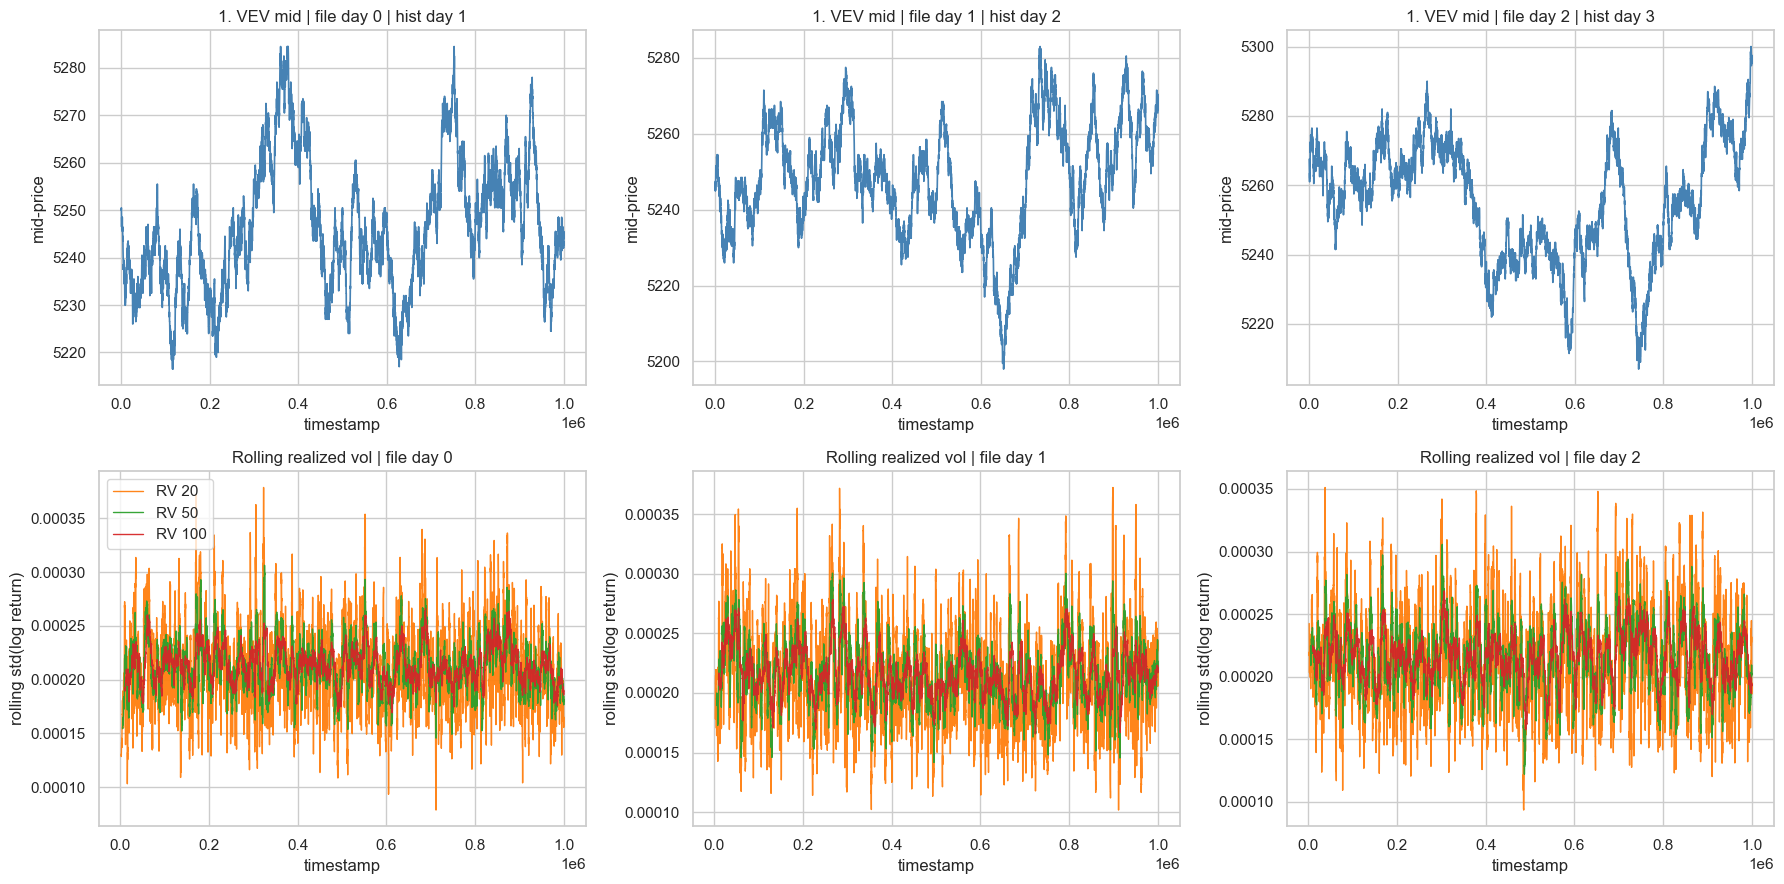

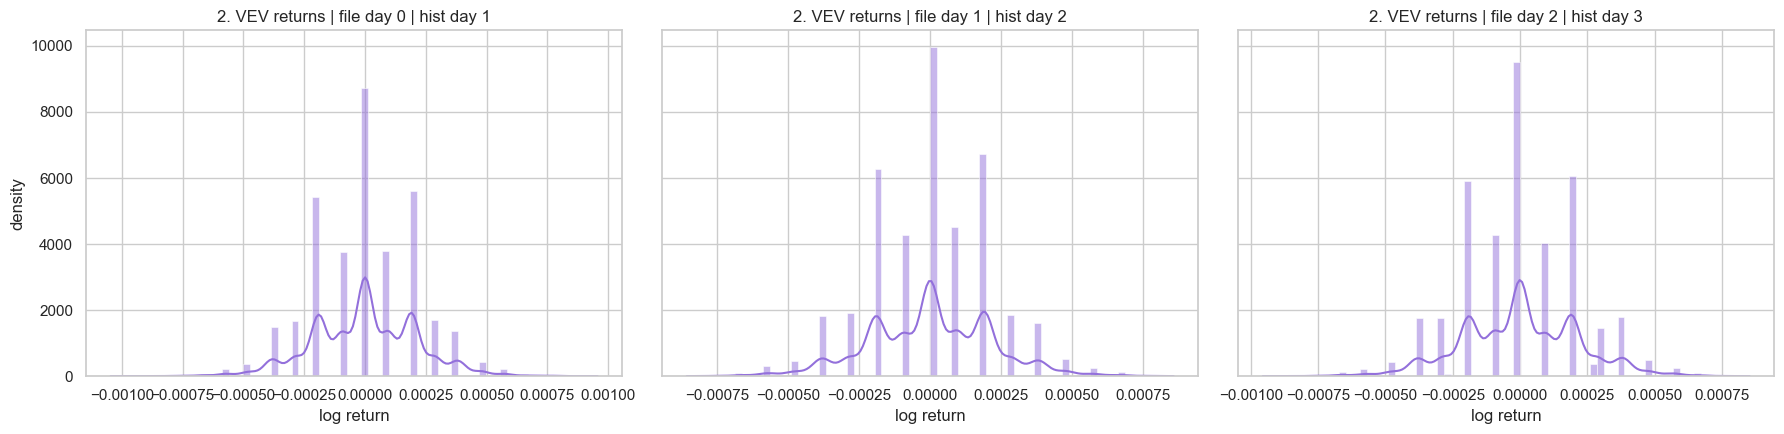

In [34]:
# 1. VELVETFRUIT_EXTRACT mid-price over time + rolling realized vol (20, 50, 100)
fig, axes = plt.subplots(2, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 9), sharex=False)
for col_idx, day in enumerate(FILE_DAYS):
    day_df = vev[vev["file_day"] == day].sort_values("timestamp")
    top_ax = axes[0, col_idx]
    bot_ax = axes[1, col_idx]

    top_ax.plot(day_df["timestamp"], day_df["mid_price"], color="steelblue", linewidth=1.2)
    top_ax.set_title(f"1. VEV mid | file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]}")
    top_ax.set_xlabel("timestamp")
    top_ax.set_ylabel("mid-price")

    for window, color in zip((20, 50, 100), ("tab:orange", "tab:green", "tab:red")):
        bot_ax.plot(day_df["timestamp"], day_df[f"rv_{window}"], label=f"RV {window}", linewidth=1.0, alpha=0.95, color=color)
    bot_ax.set_title(f"Rolling realized vol | file day {day}")
    bot_ax.set_xlabel("timestamp")
    bot_ax.set_ylabel("rolling std(log return)")
    if col_idx == 0:
        bot_ax.legend()

savefig("01_vev_mid_and_realized_vol.png")
plt.show()

# 2. Returns distribution histogram for VEV
fig, axes = plt.subplots(1, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 4.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, day in zip(axes, FILE_DAYS):
    day_df = vev[vev["file_day"] == day]
    sns.histplot(day_df["log_return"].dropna(), bins=70, kde=True, color="mediumpurple", stat="density", ax=ax)
    ax.set_title(f"2. VEV returns | file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]}")
    ax.set_xlabel("log return")
    ax.set_ylabel("density")
savefig("02_vev_return_histogram.png")
plt.show()

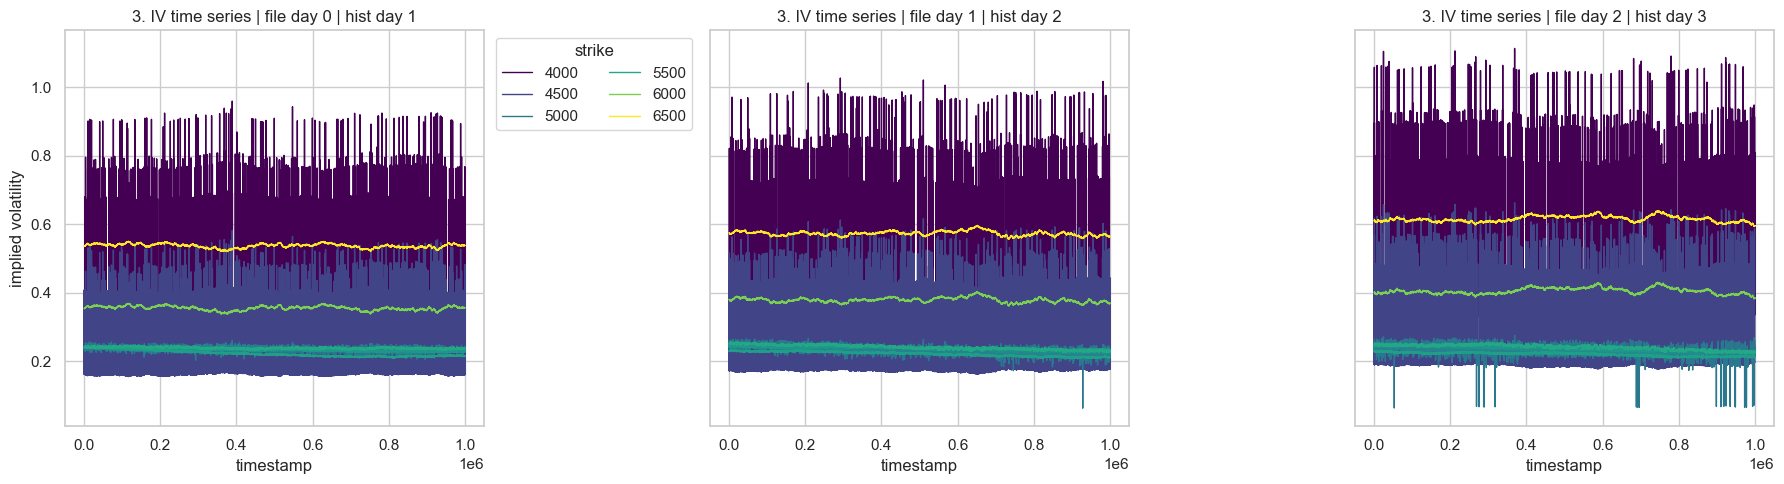

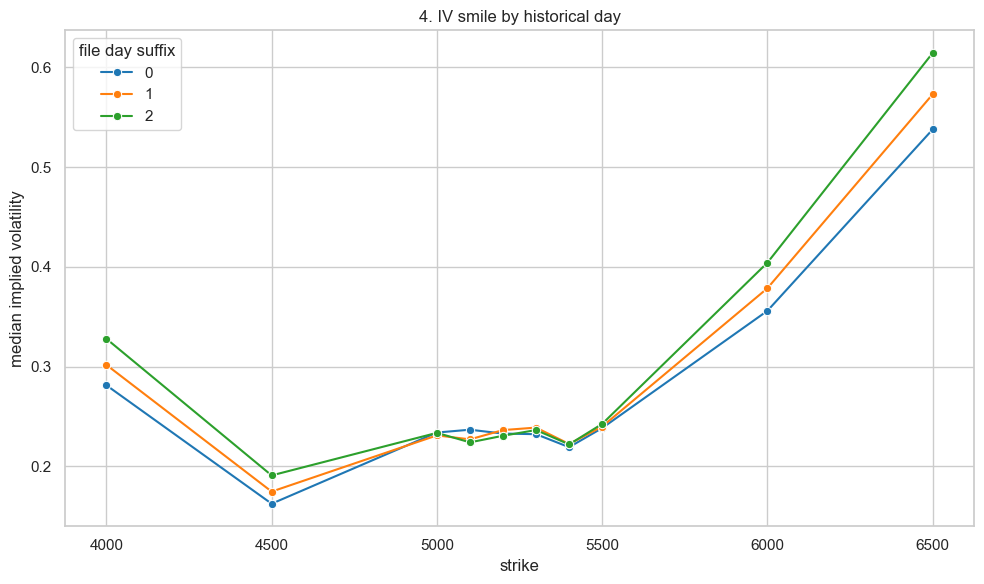

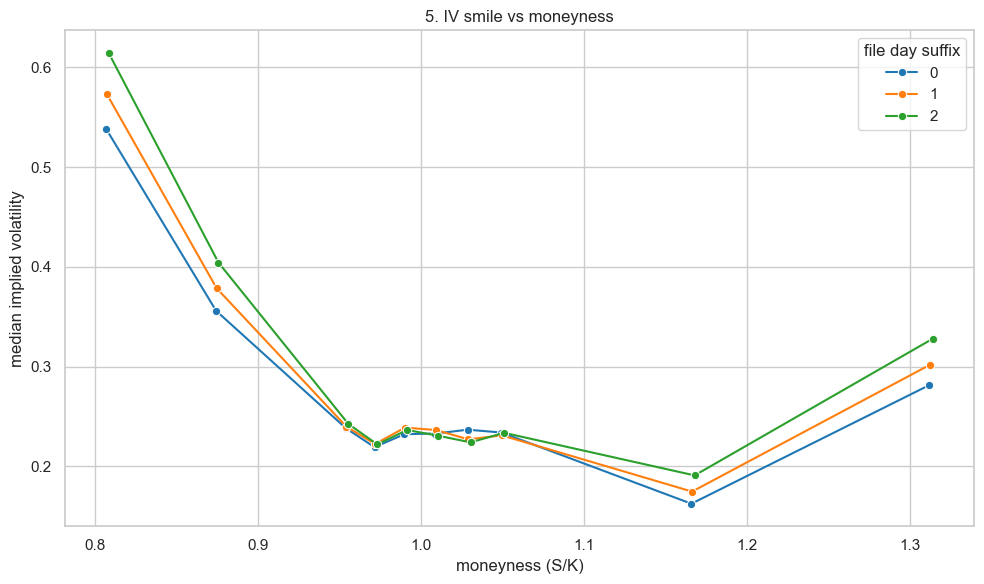

In [35]:
# 3. IV time series for all 10 strikes on one chart
fig, axes = plt.subplots(1, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, day in zip(axes, FILE_DAYS):
    day_df = options[options["file_day"] == day].sort_values("timestamp")
    sns.lineplot(data=day_df, x="timestamp", y="bs_iv", hue="strike", palette="viridis", linewidth=1.0, ax=ax)
    ax.set_title(f"3. IV time series | file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("implied volatility")
    if day != FILE_DAYS[0]:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    else:
        ax.legend(title="strike", ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
savefig("03_iv_time_series_all_strikes.png")
plt.show()

# 4. IV smile (IV vs strike) for each historical day overlaid on one chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=smile_daily, x="strike", y="median_iv", hue="file_day", marker="o", palette="tab10")
plt.title("4. IV smile by historical day")
plt.xlabel("strike")
plt.ylabel("median implied volatility")
plt.legend(title="file day suffix")
savefig("04_iv_smile_by_day.png")
plt.show()

# 5. IV smile vs moneyness (S/K) for each historical day overlaid on one chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=smile_daily.sort_values("moneyness"), x="moneyness", y="median_iv", hue="file_day", marker="o", palette="tab10")
plt.title("5. IV smile vs moneyness")
plt.xlabel("moneyness (S/K)")
plt.ylabel("median implied volatility")
plt.legend(title="file day suffix")
savefig("05_iv_smile_vs_moneyness.png")
plt.show()

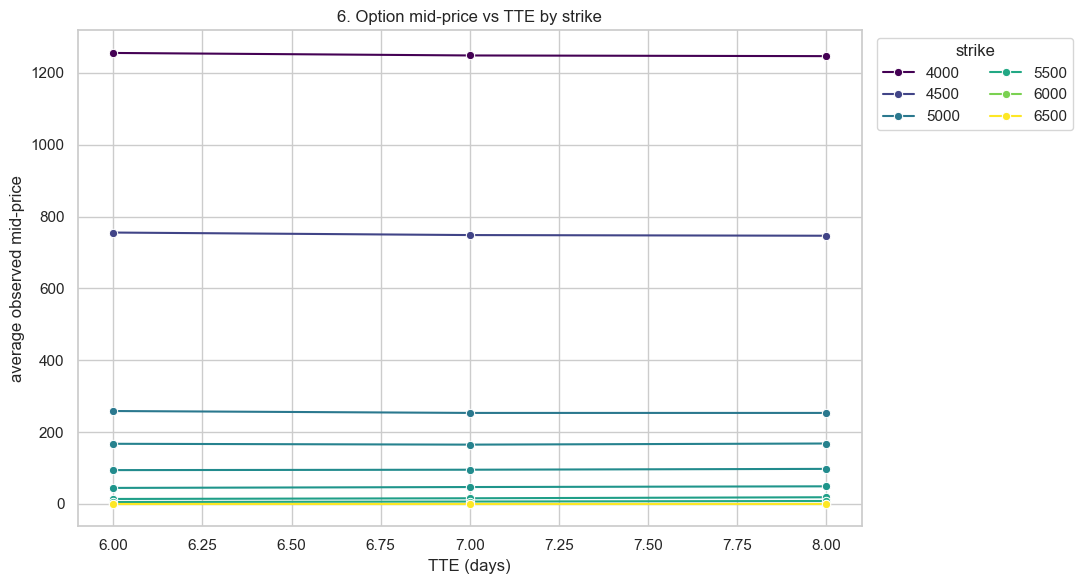

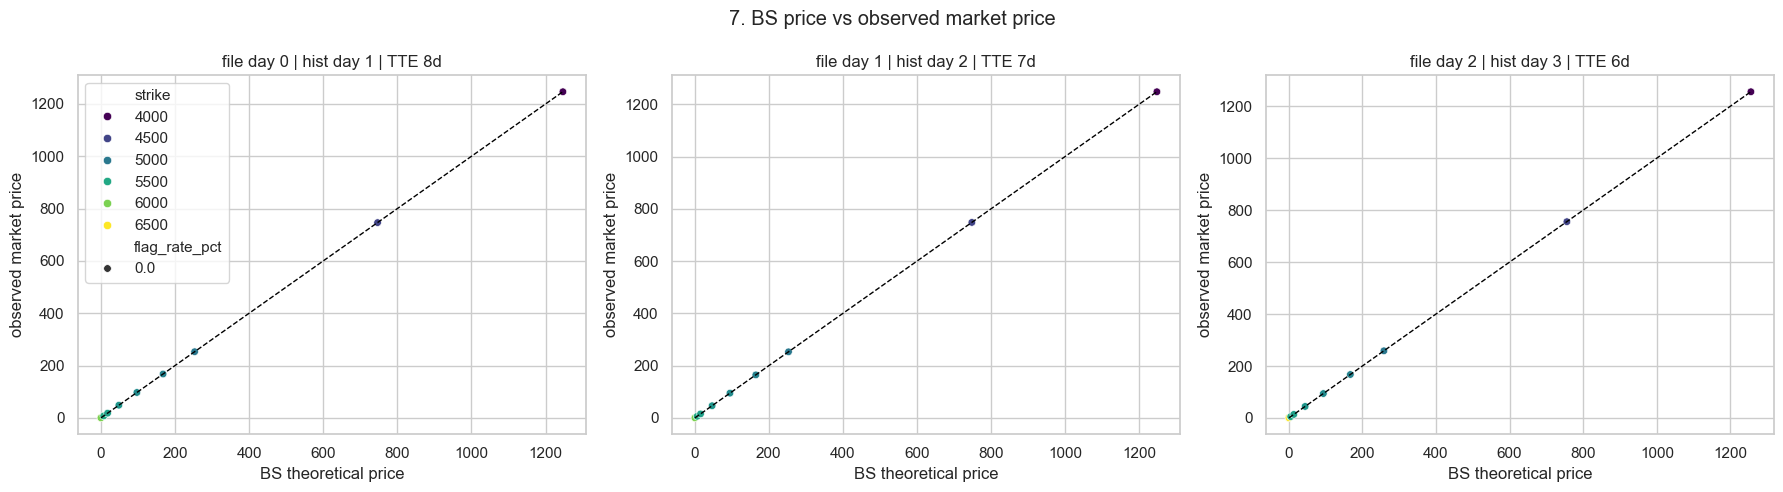

In [36]:
# 6. Option mid-price vs TTE for each strike (decay curve)
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=candidate_summary.sort_values("tte_days", ascending=False),
    x="tte_days",
    y="observed_mid",
    hue="strike",
    marker="o",
    palette="viridis",
)
plt.title("6. Option mid-price vs TTE by strike")
plt.xlabel("TTE (days)")
plt.ylabel("average observed mid-price")
plt.legend(title="strike", ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
savefig("06_option_mid_vs_tte.png")
plt.show()

# 7. BS theoretical price vs observed market price per strike per day
fig, axes = plt.subplots(1, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 5), sharex=False, sharey=False)
axes = np.atleast_1d(axes)
for ax, day in zip(axes, FILE_DAYS):
    day_df = candidate_summary[candidate_summary["file_day"] == day].copy()
    sns.scatterplot(
        data=day_df,
        x="bs_mid",
        y="observed_mid",
        hue="strike",
        size="flag_rate_pct",
        sizes=(30, 180),
        palette="viridis",
        ax=ax,
        legend=(day == FILE_DAYS[0]),
    )
    lo = min(day_df["bs_mid"].min(), day_df["observed_mid"].min())
    hi = max(day_df["bs_mid"].max(), day_df["observed_mid"].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.0)
    ax.set_title(
        f"file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]} | TTE {TTE_BY_FILE_DAY[day]:.0f}d"
    )
    ax.set_xlabel("BS theoretical price")
    ax.set_ylabel("observed market price")
fig.suptitle("7. BS price vs observed market price")
savefig("07_bs_vs_observed_by_day.png")
plt.show()

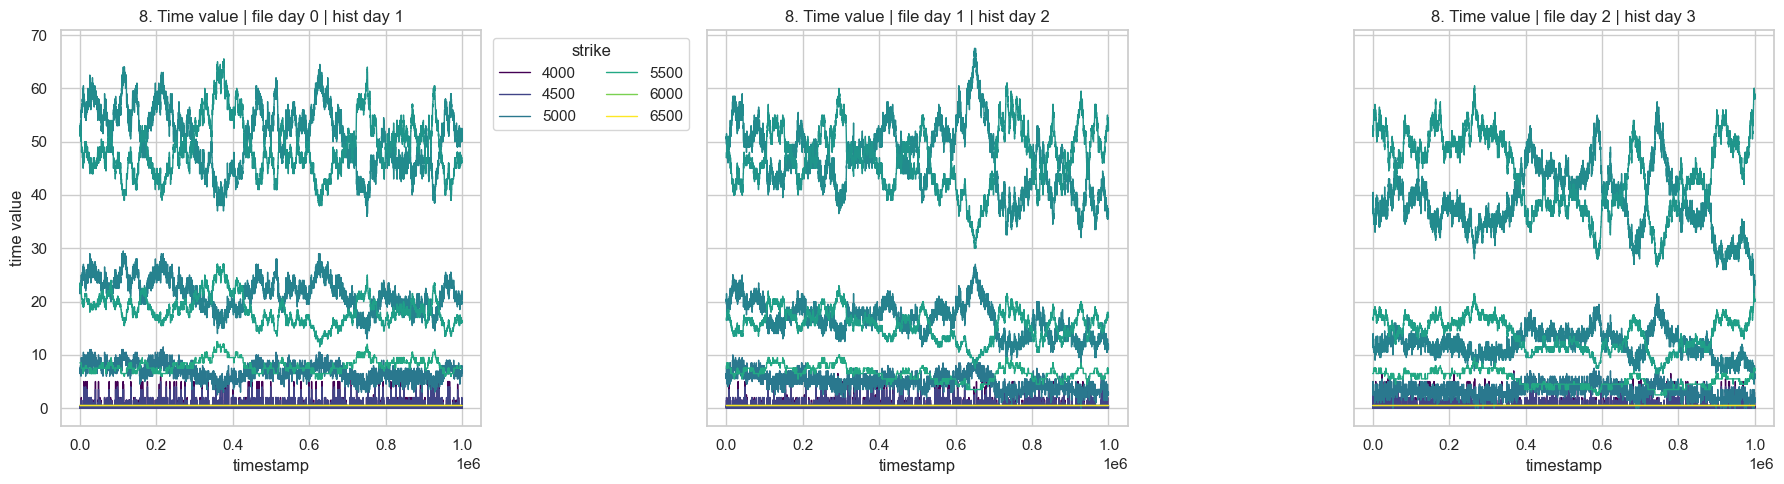

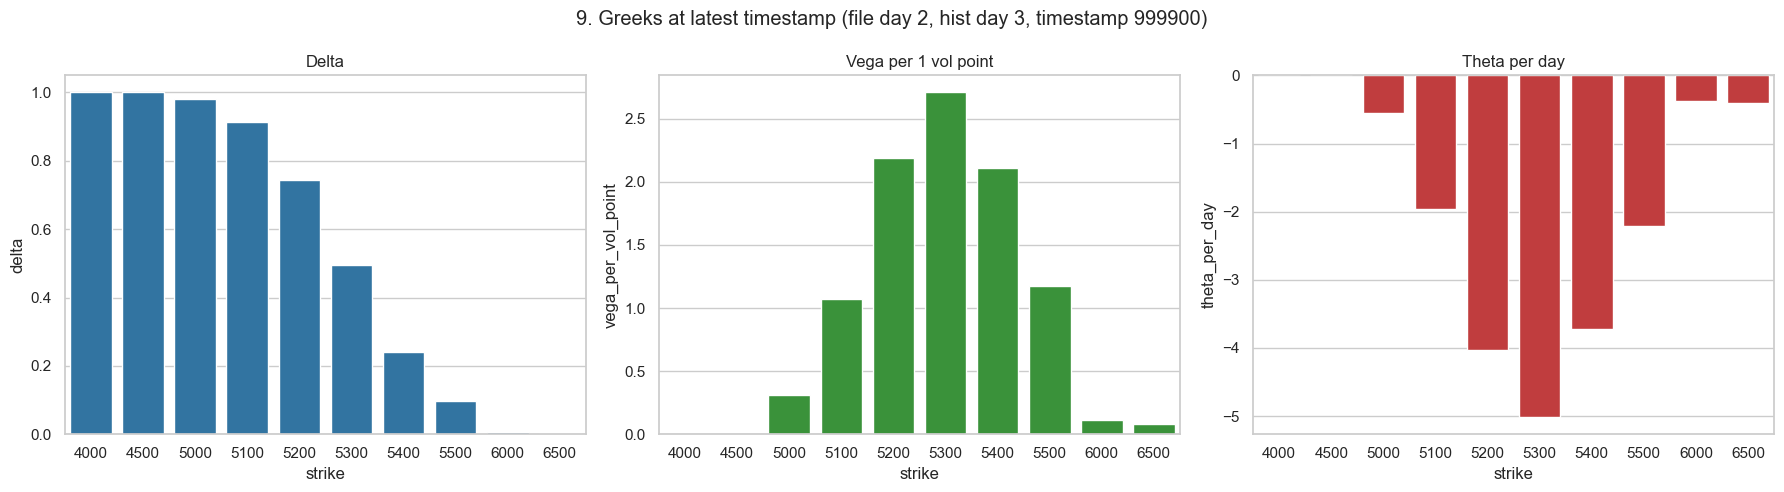

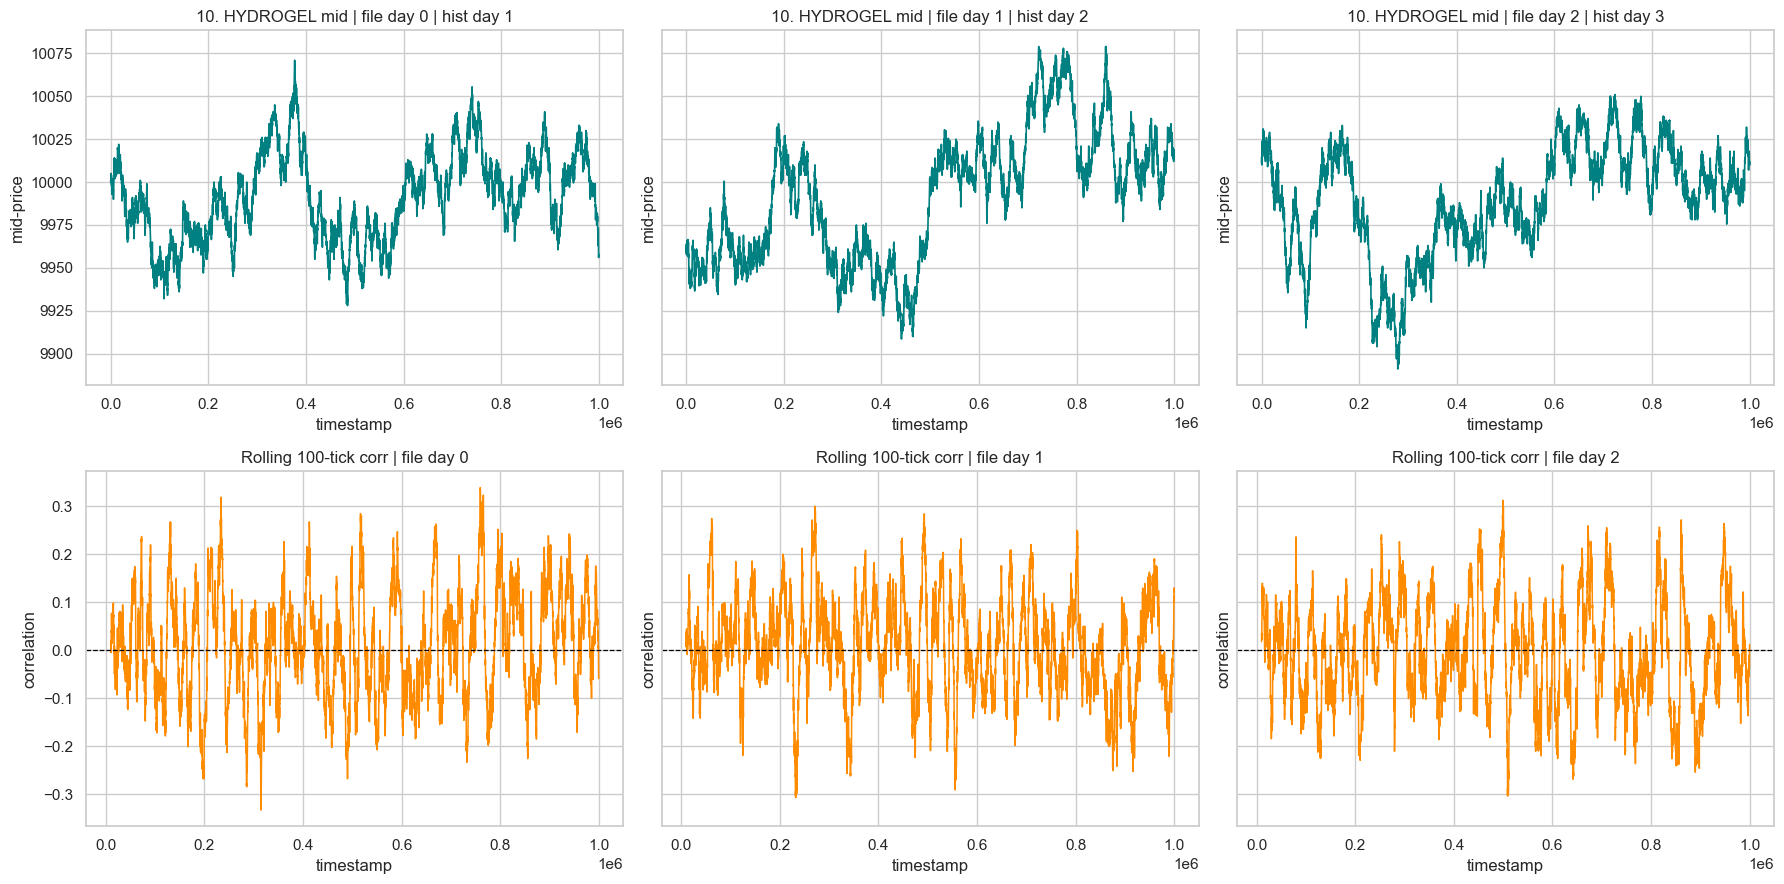

In [37]:
# 8. Time value remaining per strike over time
fig, axes = plt.subplots(1, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, day in zip(axes, FILE_DAYS):
    day_df = options[options["file_day"] == day].sort_values("timestamp")
    sns.lineplot(
        data=day_df,
        x="timestamp",
        y="time_value",
        hue="strike",
        palette="viridis",
        linewidth=1.0,
        ax=ax,
    )
    ax.set_title(f"8. Time value | file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("time value")
    if day != FILE_DAYS[0]:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    else:
        ax.legend(title="strike", ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
savefig("08_time_value_over_time.png")
plt.show()

# 9. Delta, vega, theta per strike at the latest available timestamp
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metrics = [
    ("delta", "Delta", "tab:blue"),
    ("vega_per_vol_point", "Vega per 1 vol point", "tab:green"),
    ("theta_per_day", "Theta per day", "tab:red"),
]
for ax, (column, title, color) in zip(axes, metrics):
    sns.barplot(data=latest_snapshot, x="strike", y=column, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("strike")
    ax.set_ylabel(column)
fig.suptitle(
    f"9. Greeks at latest timestamp (file day {latest_day}, hist day {HISTORICAL_DAY_BY_FILE_DAY[latest_day]}, timestamp {latest_timestamp})"
)
savefig("09_latest_greeks.png")
plt.show()

# 10. HYDROGEL_PACK mid-price over time + correlation with VEV
fig, axes = plt.subplots(2, len(FILE_DAYS), figsize=(6 * len(FILE_DAYS), 9), sharex=False, sharey='row')
for col_idx, day in enumerate(FILE_DAYS):
    hydro_day = hydro[hydro["file_day"] == day].sort_values("timestamp")
    corr_day = corr_df[corr_df["file_day"] == day].sort_values("timestamp")
    top_ax = axes[0, col_idx]
    bot_ax = axes[1, col_idx]

    top_ax.plot(hydro_day["timestamp"], hydro_day["mid_price"], color="teal", linewidth=1.2)
    top_ax.set_title(f"10. HYDROGEL mid | file day {day} | hist day {HISTORICAL_DAY_BY_FILE_DAY[day]}")
    top_ax.set_xlabel("timestamp")
    top_ax.set_ylabel("mid-price")

    bot_ax.plot(corr_day["timestamp"], corr_day["rolling_corr_100"], color="darkorange", linewidth=1.1)
    bot_ax.axhline(0, color="black", linestyle="--", linewidth=0.9)
    bot_ax.set_title(f"Rolling 100-tick corr | file day {day}")
    bot_ax.set_xlabel("timestamp")
    bot_ax.set_ylabel("correlation")
savefig("10_hydrogel_and_correlation.png")
plt.show()

## Candidate Screen And Extra Diagnostics

## Strategy Questions

This section adds lightweight diagnostics to answer the remaining practical trading questions without building a full trading model.

In [38]:
UNDERLYING_POSITION_LIMIT = 200
OPTION_POSITION_LIMIT = 300
FOCUS_STRIKES = [5200, 5300, 5400]
ANOMALY_STRIKES = [6000, 6500]

options_diag = options.copy()
options_diag["delta_all"], options_diag["vega_all"], options_diag["theta_all"] = bs_call_greeks(
    options_diag["spot_mid"].to_numpy(),
    options_diag["strike"].to_numpy(),
    options_diag["tte_years"].to_numpy(),
    options_diag["bs_iv"].to_numpy(),
)

vev_drive_rows = []
for day in FILE_DAYS:
    day_df = vev[vev["file_day"] == day].sort_values("timestamp")
    slope, intercept = np.polyfit(day_df["timestamp"], day_df["mid_price"], 1)
    vev_drive_rows.append(
        {
            "file_day": day,
            "historical_day": HISTORICAL_DAY_BY_FILE_DAY[day],
            "start_mid": float(day_df["mid_price"].iloc[0]),
            "end_mid": float(day_df["mid_price"].iloc[-1]),
            "net_change": float(day_df["mid_price"].iloc[-1] - day_df["mid_price"].iloc[0]),
            "linear_slope_per_timestamp": float(slope),
            "lag1_return_autocorr": float(day_df["log_return"].dropna().autocorr(lag=1)),
        }
    )
vev_drive_summary = pd.DataFrame(vev_drive_rows)

corr_summary = (
    corr_df.groupby(["file_day", "historical_day"], as_index=False)
    .agg(
        return_corr=("vev_log_return", lambda s: s.corr(corr_df.loc[s.index, "hydro_log_return"])),
        level_corr=("vev_mid", lambda s: s.corr(corr_df.loc[s.index, "hydro_mid"])),
        avg_rolling_corr_100=("rolling_corr_100", "mean"),
    )
)
overall_return_corr = float(corr_df["vev_log_return"].corr(corr_df["hydro_log_return"]))

realized_vol_rows = []
for day in FILE_DAYS:
    day_returns = vev.loc[vev["file_day"] == day, "log_return"].dropna()
    daily_realized_vol = float(np.sqrt(np.square(day_returns).sum()))
    annualized_realized_vol = float(daily_realized_vol * np.sqrt(365.0))
    realized_vol_rows.append(
        {
            "file_day": day,
            "historical_day": HISTORICAL_DAY_BY_FILE_DAY[day],
            "daily_realized_vol": daily_realized_vol,
            "annualized_realized_vol": annualized_realized_vol,
        }
    )
realized_vol_summary = pd.DataFrame(realized_vol_rows)

atm_iv_summary = (
    options_diag[options_diag["strike"].isin(FOCUS_STRIKES)]
    .groupby("file_day", as_index=False)
    .agg(atm_median_iv=("bs_iv", "median"), atm_mean_iv=("bs_iv", "mean"))
)
rv_vs_iv_summary = realized_vol_summary.merge(atm_iv_summary, on="file_day", how="left")
rv_vs_iv_summary["rv_minus_atm_iv"] = rv_vs_iv_summary["annualized_realized_vol"] - rv_vs_iv_summary["atm_median_iv"]

iv_dynamics_rows = []
for (day, strike), group in options_diag.groupby(["file_day", "strike"]):
    group = group.sort_values("timestamp")
    iv_series = group["bs_iv"].dropna()
    iv_changes = iv_series.diff().dropna()
    iv_dynamics_rows.append(
        {
            "file_day": day,
            "historical_day": HISTORICAL_DAY_BY_FILE_DAY[day],
            "strike": strike,
            "iv_level_autocorr_lag1": float(iv_series.autocorr(lag=1)),
            "iv_change_autocorr_lag1": float(iv_changes.autocorr(lag=1)),
            "iv_std": float(iv_series.std()),
            "iv_range": float(iv_series.max() - iv_series.min()),
        }
    )
iv_dynamics_summary = pd.DataFrame(iv_dynamics_rows)
iv_dynamics_focus = (
    iv_dynamics_summary[iv_dynamics_summary["strike"].isin(FOCUS_STRIKES)]
    .groupby("strike", as_index=False)
    .agg(
        mean_iv_level_autocorr_lag1=("iv_level_autocorr_lag1", "mean"),
        mean_iv_change_autocorr_lag1=("iv_change_autocorr_lag1", "mean"),
        mean_iv_std=("iv_std", "mean"),
        mean_iv_range=("iv_range", "mean"),
    )
)

vev_half_spread_by_day = vev.groupby("file_day")["spread"].mean() / 2.0
hedge_cost_rows = []
for (day, strike), group in options_diag[options_diag["strike"].isin(FOCUS_STRIKES)].groupby(["file_day", "strike"]):
    group = group.sort_values("timestamp")
    half_spread = float(vev_half_spread_by_day.loc[day])
    avg_abs_delta_change = float(group["delta_all"].diff().abs().mean())
    daily_abs_delta_turnover = float(group["delta_all"].diff().abs().sum())
    mean_abs_theta = float(group["theta_all"].abs().mean())
    hedge_cost_rows.append(
        {
            "file_day": day,
            "historical_day": HISTORICAL_DAY_BY_FILE_DAY[day],
            "strike": strike,
            "vev_half_spread": half_spread,
            "avg_abs_delta_change": avg_abs_delta_change,
            "est_cost_per_rehedge": avg_abs_delta_change * half_spread,
            "est_tickwise_daily_hedge_cost": daily_abs_delta_turnover * half_spread,
            "mean_abs_theta_per_day": mean_abs_theta,
            "daily_cost_to_theta_ratio": (daily_abs_delta_turnover * half_spread) / mean_abs_theta if mean_abs_theta > 0 else np.nan,
        }
    )
hedge_cost_summary = pd.DataFrame(hedge_cost_rows)

anomaly_symbols = [f"VEV_{strike}" for strike in ANOMALY_STRIKES]
anomaly_trade_summary = (
    trades[trades["symbol"].isin(anomaly_symbols)]
    .groupby(["symbol", "file_day"], as_index=False)
    .agg(
        trades=("symbol", "size"),
        total_quantity=("quantity", "sum"),
        unique_timestamps=("timestamp", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        zero_timestamp_share=("timestamp", lambda s: float((s == 0).mean())),
        zero_price_share=("price", lambda s: float((s == 0).mean())),
        unique_prices=("price", "nunique"),
    )
)

focus_trade_counts = (
    trades[trades["symbol"].isin([f"VEV_{strike}" for strike in FOCUS_STRIKES])]
    .assign(strike=lambda df: df["symbol"].str.split("_").str[1].astype(int))
    .groupby(["file_day", "strike"], as_index=False)
    .agg(option_trade_count=("symbol", "size"), option_traded_qty=("quantity", "sum"))
)

focus_option_spreads = (
    options_diag[options_diag["strike"].isin(FOCUS_STRIKES)]
    .groupby(["file_day", "strike"], as_index=False)
    .agg(
        mean_option_spread=("spread", "mean"),
        mean_delta=("delta_all", "mean"),
        max_delta=("delta_all", "max"),
    )
)

latest_limit_summary = latest_snapshot[["strike", "delta"]].copy()
latest_limit_summary["delta_for_300_lot_latest"] = latest_limit_summary["delta"] * OPTION_POSITION_LIMIT
latest_limit_summary["fits_underlying_limit_latest"] = latest_limit_summary["delta_for_300_lot_latest"].abs() <= UNDERLYING_POSITION_LIMIT
latest_limit_summary = latest_limit_summary[latest_limit_summary["strike"].isin(FOCUS_STRIKES)]

market_making_summary = (
    hedge_cost_summary.merge(focus_option_spreads, on=["file_day", "strike"], how="left")
    .merge(focus_trade_counts, on=["file_day", "strike"], how="left")
    .sort_values(["strike", "file_day"])
)

print("Question 1: What drives VEV price?")
display(vev_drive_summary)
display(corr_summary)
print(
    f"Overall contemporaneous VEV vs HYDRO log-return correlation: {overall_return_corr:.4f}. "
    "That is effectively flat."
)
print(
    "Takeaway: VEV does not show one stable drift regime across the three days, and its lag-1 return autocorrelation is mildly negative "
    "(around -0.15 to -0.17), which is more consistent with short-horizon mean reversion/noise than with a strong PEPPER-style trend."
)
print()

print("Question 2: Realized vol versus implied vol")
display(rv_vs_iv_summary)
print(
    "Takeaway: annualized realized vol from intraday realized variance is about 0.41, while median ATM IV is about 0.23. "
    "On this proxy, realized vol is materially above implied vol, which leans more long-gamma/long-vol than short-vega."
)
print()

print("Question 3: Intraday IV dynamics")
display(iv_dynamics_focus)
print(
    "Takeaway: IV levels are highly persistent intraday, but IV changes have negative lag-1 autocorrelation for the near-ATM strikes. "
    "That means IV shocks tend to partially mean-revert on the next step rather than trend further."
)
print()

print("Question 4: Can you delta-hedge in practice?")
display(hedge_cost_summary)
print(
    "Takeaway: using VEV half-spread as the hedge friction proxy, tick-by-tick hedging costs are roughly 9x to 13x daily theta for the near-ATM strikes. "
    "That suggests continuous delta-hedging is too expensive; any vol strategy would need sparse hedging and careful inventory control."
)
print()

print("Question 5: VEV_6000 / VEV_6500 anomaly")
display(anomaly_trade_summary)
print(
    "Takeaway: these trades are not concentrated at timestamp 0. They occur across many timestamps on every day, and every recorded trade prints at price 0.0. "
    "So this looks more like a repeated bot/program flow at the floor price than a one-off initialization event."
)
print()

print("Question 6: Strike selection for market making")
display(market_making_summary)
display(latest_limit_summary)
print(
    "Takeaway: the best quoting candidates still look like the near-ATM strikes, but the hedge constraint matters. "
    "At the latest snapshot a full 300-lot in VEV_5200 needs more than 200 units of VEV to fully delta-hedge, while VEV_5300 and VEV_5400 fit more comfortably inside the underlying limit."
)
print(
    "Practical read: VEV_5300 / VEV_5400 are easier to warehouse and hedge than VEV_5200, even before considering spread capture and fill intensity."
)

Question 1: What drives VEV price?


,file_day,historical_day,start_mid,end_mid,net_change,linear_slope_per_timestamp,lag1_return_autocorr
0,0,1,5250.0,5244.0,-6.0,0.000013,-0.151067
1,1,2,5245.0,5265.5,20.5,0.000008,-0.169349
2,2,3,5267.5,5295.5,28.0,-0.000007,-0.155269


,file_day,historical_day,return_corr,level_corr,avg_rolling_corr_100
0,0,1,0.011068,0.500105,0.012712
1,1,2,0.012007,0.183685,0.008429
2,2,3,-0.005006,-0.222020,-0.005218


Overall contemporaneous VEV vs HYDRO log-return correlation: 0.0060. That is effectively flat.
Takeaway: VEV does not show one stable drift regime across the three days, and its lag-1 return autocorrelation is mildly negative (around -0.15 to -0.17), which is more consistent with short-horizon mean reversion/noise than with a strong PEPPER-style trend.

Question 2: Realized vol versus implied vol


,file_day,historical_day,daily_realized_vol,annualized_realized_vol,atm_median_iv,atm_mean_iv,rv_minus_atm_iv
0,0,1,0.021357,0.408016,0.231010,0.228832,0.177006
1,1,2,0.021621,0.413075,0.234102,0.231630,0.178972
2,2,3,0.021656,0.413733,0.228275,0.229836,0.185457


...

,symbol,file_day,trades,total_quantity,unique_timestamps,first_timestamp,last_timestamp,zero_timestamp_share,zero_price_share,unique_prices
0,VEV_6000,0,91,320,91,2900,994300,0.0,1.0,1
1,VEV_6000,1,98,345,98,4500,990300,0.0,1.0,1
2,VEV_6000,2,95,337,95,13100,993800,0.0,1.0,1
3,VEV_6500,0,91,320,91,2900,994300,0.0,1.0,1
4,VEV_6500,1,98,345,98,4500,990300,0.0,1.0,1
5,VEV_6500,2,95,337,95,13100,993800,0.0,1.0,1


Takeaway: these trades are not concentrated at timestamp 0. They occur across many timestamps on every day, and every recorded trade prints at price 0.0. So this looks more like a repeated bot/program flow at the floor price than a one-off initialization event.

Question 6: Strike selection for market making


,file_day,historical_day,strike,vev_half_spread,avg_abs_delta_change,est_cost_per_rehedge,est_tickwise_daily_hedge_cost,mean_abs_theta_per_day,daily_cost_to_theta_ratio,mean_option_spread,mean_delta,max_delta,option_trade_count,option_traded_qty
0,0,1,5200,2.49675,0.002046,0.005110,51.090428,4.316330,11.836545,2.9260,0.608605,0.690114,3,15
3,1,2,5200,2.49230,0.002226,0.005547,55.461054,4.645026,11.939881,2.8779,0.617869,0.697374,7,22
6,2,3,5200,2.49315,0.002525,0.006296,62.951110,4.835390,13.018828,2.8605,0.643481,0.757203,8,26
1,0,1,5300,2.49675,0.001718,0.004289,42.884705,4.315971,9.936283,2.1606,0.390925,0.473120,37,128
4,1,2,5300,2.49230,0.001808,0.004505,45.045997,4.732326,9.518786,2.1088,0.390194,0.467457,39,130
7,2,3,5300,2.49315,0.001973,0.004919,49.183281,5.100337,9.643143,2.0510,0.396594,0.505660,45,162
2,0,1,5400,2.49675,0.001254,0.003130,31.300381,2.968162,10.545376,1.4297,0.195299,0.260925,64,218
5,1,2,5400,2.49230,0.001312,0.003270,32.693834,3.011420,10.856617,1.3864,0.180988,0.238513,81,286
8,2,3,5400,2.49315,0.001378,0.003435,34.346883,3.148057,10.910503,1.3282,0.173199,0.251024,80,283


,strike,delta,delta_for_300_lot_latest,fits_underlying_limit_latest
4,5200,0.743806,223.141760,False
5,5300,0.493792,148.137672,True
6,5400,0.239743,71.922785,True


Takeaway: the best quoting candidates still look like the near-ATM strikes, but the hedge constraint matters. At the latest snapshot a full 300-lot in VEV_5200 needs more than 200 units of VEV to fully delta-hedge, while VEV_5300 and VEV_5400 fit more comfortably inside the underlying limit.
Practical read: VEV_5300 / VEV_5400 are easier to warehouse and hedge than VEV_5200, even before considering spread capture and fill intensity.


No strike/day buckets breached the >2% threshold. Closest candidates are shown instead.


,file_day,tte_days,strike,observed_mid,bs_mid,mean_abs_pct_dev,max_abs_pct_dev,flag_rate_pct
21,2,6.0,4500,755.40185,755.59960,2.626484e-04,7.947020e-03,0.0
1,0,8.0,4500,746.52160,746.72995,2.795352e-04,7.412399e-03,0.0
11,1,7.0,4500,748.40525,748.61645,2.826296e-04,6.258693e-03,0.0
20,2,6.0,4000,1255.39735,1255.52315,1.004094e-04,5.582137e-03,0.0
0,0,8.0,4000,1246.52410,1246.63930,9.264997e-05,5.349794e-03,0.0
10,1,7.0,4000,1248.40795,1248.52775,9.630512e-05,4.769475e-03,0.0
22,2,6.0,5000,258.54470,258.54485,5.469568e-07,1.865672e-03,0.0
12,1,7.0,5000,253.26300,253.26300,2.178435e-15,3.566646e-12,0.0
8,0,8.0,6000,0.50000,0.50000,5.409980e-13,1.165290e-12,0.0
9,0,8.0,6500,0.50000,0.50000,6.321358e-13,1.165290e-12,0.0


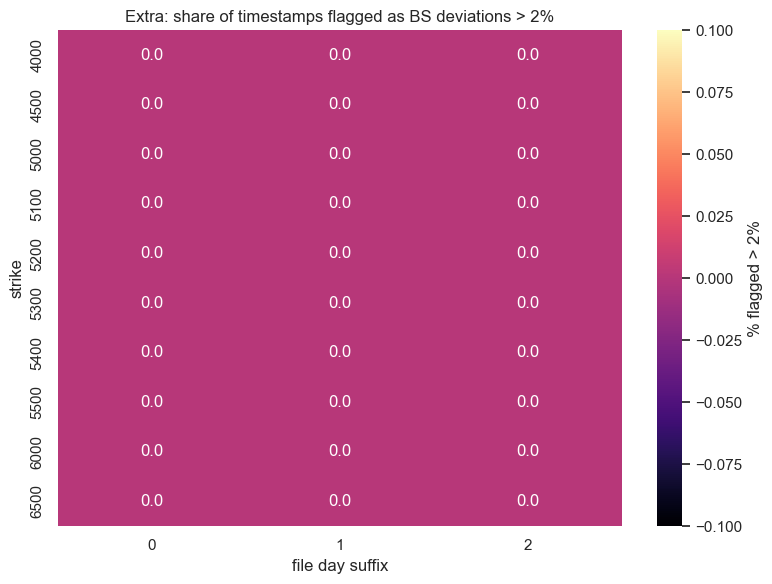

,product,file_day,mean_spread,median_spread
0,HYDROGEL_PACK,0,15.7010,16.0
1,HYDROGEL_PACK,1,15.7264,16.0
2,HYDROGEL_PACK,2,15.7350,16.0
3,VELVETFRUIT_EXTRACT,0,4.9935,5.0
4,VELVETFRUIT_EXTRACT,1,4.9846,5.0
5,VELVETFRUIT_EXTRACT,2,4.9863,5.0
6,VEV_4000,0,20.7654,21.0
7,VEV_4000,1,20.7745,21.0
8,VEV_4000,2,20.9005,21.0
9,VEV_4500,0,15.7842,16.0


,product,strike,bs_iv,delta,vega_per_vol_point,theta_per_day
0,VEV_4000,4000,0.335570,1.000000,1.373108e-09,-3.839781e-09
1,VEV_4500,4500,0.196808,1.000000,2.293963e-09,-3.762248e-09
2,VEV_5000,5000,0.216269,0.981450,3.083670e-01,-5.557507e-01
3,VEV_5100,5100,0.218059,0.913000,1.075047e+00,-1.953535e+00
4,VEV_5200,5200,0.221465,0.743806,2.185494e+00,-4.033420e+00
5,VEV_5300,5300,0.222253,0.493792,2.708281e+00,-5.016021e+00
6,VEV_5400,5400,0.211486,0.239743,2.109431e+00,-3.717633e+00
7,VEV_5500,5500,0.225967,0.097943,1.173558e+00,-2.209882e+00
8,VEV_6000,6000,0.384384,0.006041,1.161340e-01,-3.720003e-01
9,VEV_6500,6500,0.595567,0.004075,8.178488e-02,-4.059029e-01


In [39]:
primary_candidates = candidate_summary[candidate_summary["flag_rate"] > 0].copy()
primary_candidates = primary_candidates.sort_values(["flag_rate", "mean_abs_pct_dev"], ascending=False)

candidate_columns = [
    "file_day",
    "tte_days",
    "strike",
    "observed_mid",
    "bs_mid",
    "mean_abs_pct_dev",
    "max_abs_pct_dev",
    "flag_rate_pct",
]

if primary_candidates.empty:
    print("No strike/day buckets breached the >2% threshold. Closest candidates are shown instead.")
    display(candidate_summary[candidate_columns].sort_values("max_abs_pct_dev", ascending=False).head(20))
else:
    print("Primary trading candidates (observed vs BS deviation > 2% somewhere in the day):")
    display(primary_candidates[candidate_columns].head(20))

heatmap_df = smile_daily.pivot(index="strike", columns="file_day", values="flag_rate_pct").sort_index(ascending=True)
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="magma", cbar_kws={"label": "% flagged > 2%"})
plt.title("Extra: share of timestamps flagged as BS deviations > 2%")
plt.xlabel("file day suffix")
plt.ylabel("strike")
savefig("11_candidate_heatmap.png")
plt.show()

spread_summary = (
    prices.groupby(["product", "file_day"], as_index=False)
    .agg(mean_spread=("spread", "mean"), median_spread=("spread", "median"))
    .sort_values(["product", "file_day"])
)

display(spread_summary.head(20))
display(latest_snapshot[["product", "strike", "bs_iv", "delta", "vega_per_vol_point", "theta_per_day"]])